# Solution: Set Difference, Part 2 (Monthly Algorithmic Challenge, October 2026)

## 0. The task

Pick $K$ distinct symbols ($2 \le K \le 8$) from the alphabet $\{\mathtt{a}, \dots, \mathtt{p}\}$ to form a set $X$, and let $Y$ be an independent random permutation of $X$. The model reads

$$[\mathrm{BOS}]\; x_1 \dots x_K\; [\mathrm{SEP}]\; y_1 \dots y_K\; [\mathrm{EOS}]$$

At $\mathrm{SEP}$ and after each $y_i$ it must output the uniform distribution over the symbols of $X$ that have not yet appeared in $Y$, and after $y_K$ it must predict $\mathrm{EOS}$.

## 1. The model, written out

Positions run $0$ to $2K+2$. Position 0 is $\mathrm{BOS}$, positions $1$ to $K$ hold $X$, position $K+1$ is $\mathrm{SEP}$, positions $K+2$ to $2K+1$ hold $Y$, and position $2K+2$ is $\mathrm{EOS}$. Write $d = i - (K+1)$ for how far a query position $i$ sits past $\mathrm{SEP}$, so the scored positions are $d = 0, \dots, K$.

**Residual stream.** Each token $t$ has an embedding $E_t \in \mathbb{R}^{64}$, and the residual starts as $r_j = E_{x_j}$. There are no additive positional embeddings.

**A block.** Each of the two blocks is pre-norm attention with one head of width 64:

$$r \leftarrow r + W_O \sum_{j \le i} A_{ij}\, W_V\, \mathrm{RMSNorm}(r_j), \qquad A_{ij} = \mathrm{softmax}_j\!\left(\frac{(R_i W_Q \tilde r_i) \cdot (R_j W_K \tilde r_j)}{8}\right),$$

where $\tilde r = \mathrm{RMSNorm}(r)$ and $R_j$ is the rotary matrix for position $j$. Position enters only through those rotations, which depend on $i - j$.

**Readout.** $\ell_t = u_t \cdot \mathrm{RMSNorm}(r_{\text{final}})$ with $u_t$ the unembedding row of token $t$.

**Why the decomposition below is exact.** $\mathrm{RMSNorm}(r) = g \odot r / \mathrm{rms}(r)$, so

$$\ell_t = \frac{(u_t \odot g) \cdot r}{\mathrm{rms}(r)} .$$

The logit is linear in $r$ up to one positive scalar, so splitting $r$ into the embedding, the layer-0 output and the layer-1 output splits the logit exactly.

## 2. The algorithm in one paragraph

The residual carries one number per symbol, and that number is a **count**. Layer 0 is a counting head: it attends uniformly over every symbol token seen so far, and its OV circuit is a *negative* copy, so each occurrence of a symbol subtracts a fixed amount $\beta_K$ from that symbol's logit. Layer 1 is a membership head: it attends to $\mathrm{SEP}$ with weight $1.000$ at every scored position, and the residual sitting at $\mathrm{SEP}$ holds the average of the $X$ block, so its *positive* copy circuit adds a fixed $\alpha_K$ to every symbol of $X$, identically at every step. The readout is therefore

$$\ell_s \;\approx\; \alpha_K\,[s \in X] \;-\; \beta_K \cdot \mathrm{count}(s), \qquad \alpha_K \approx 2\beta_K,$$

so a symbol of $X$ that has not been consumed scores $\alpha_K - \beta_K \approx +\beta_K$, a symbol consumed in $Y$ has been counted twice and scores $\alpha_K - 2\beta_K \approx 0$, and a symbol outside $X$ scores $0$. Membership minus consumption, with the second occurrence cancelling the first. The output is uniform over the survivors for free, because the score depends on the count alone and on nothing else about the symbol.

$\mathrm{EOS}$ is a separate, positional mechanism. The value vector at $\mathrm{SEP}$ is the only one in the sequence with a negative $\mathrm{EOS}$ component, so parking layer 1 on $\mathrm{SEP}$ holds $\mathrm{EOS}$ down. Rotary position makes the other keys gain score as the query moves away from $\mathrm{SEP}$, while layer 0's average over the $K$ symbols before $\mathrm{SEP}$ sets how high the $\mathrm{SEP}$ key starts. The two cross at exactly $d = K$, attention leaks off $\mathrm{SEP}$, and $\mathrm{EOS}$ fires. The rule the model learned is **stop once as many symbols have been read after $\mathrm{SEP}$ as before it**, which agrees with "stop when the set is empty" on the training distribution but comes apart off it (section 8).

## Setup

In [1]:
%pip install -q torch einops huggingface_hub matplotlib

In [2]:
import json, importlib, random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

torch.set_grad_enabled(False)
np.set_printoptions(precision=2, suppress=True, linewidth=220)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

REPO_ID = "andyrdt/10_2026_puzzle_1"
model_py = hf_hub_download(REPO_ID, "model.py")
spec = importlib.util.spec_from_file_location("model", model_py)
mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
config = json.loads(Path(hf_hub_download(REPO_ID, "config.json")).read_text())
model = mod.Transformer.from_config(config["model"])
model.load_state_dict(torch.load(hf_hub_download(REPO_ID, "model.pt"), map_location="cpu", weights_only=True))
model.eval()

NUM_SYMBOLS, BOS, SEP, EOS = 16, 16, 17, 18
SYM = [chr(97 + k) for k in range(NUM_SYMBOLS)]
E, U = model.tok_embed.weight, model.unembed.weight
Uf = U * model.ln_final.weight          # logit_t = (u_t * g) . r / rms(r)
b0, b1 = model.blocks[0], model.blocks[1]

label = lambda t: SYM[t] if t < NUM_SYMBOLS else {BOS: "BOS", SEP: "SEP", EOS: "EOS"}[t]
encode = lambda X, Y: [BOS] + list(X) + [SEP] + list(Y) + [EOS]

def make_prompt(rng, K):
    X = rng.sample(range(NUM_SYMBOLS), K); Y = X[:]; rng.shuffle(Y)
    return encode(X, Y)

def rms(v):
    return (v.pow(2).mean(-1, keepdim=True) + 1e-5).sqrt()

def run(tokens, l0_row=None, l1_row=None):
    # l0_row / l1_row: {position: attention row to force}
    x = torch.tensor([tokens]); n = len(tokens)
    rope = mod.rope_cos_sin(n, 64, 10000.0, x.device)
    mask = torch.ones(n, n, dtype=torch.bool).tril()
    def attend(blk, r, forced):
        h = blk.ln_attn(r)
        q, k, v = blk.attn.W_Q(h), blk.attn.W_K(h), blk.attn.W_V(h)
        cos, sin = rope
        q = q * cos + mod.rotate_half(q) * sin
        k = k * cos + mod.rotate_half(k) * sin
        s = ((q @ k.transpose(-1, -2)) / 8.0).masked_fill(~mask, float("-inf"))
        p = s.softmax(-1)
        if forced:
            p = p.clone()
            for pos, row in forced.items(): p[0, pos] = row
        return blk.attn.W_O(p @ v), p[0], s[0], v[0]
    r0 = E[x]
    a0, p0, s0, v0 = attend(b0, r0, l0_row)
    r1 = r0 + a0
    a1, p1, s1, v1 = attend(b1, r1, l1_row)
    r2 = r1 + a1
    return dict(logits=model.unembed(model.ln_final(r2))[0], embed=r0[0], L0=a0[0], L1=a1[0],
                final=r2[0], p0=p0, p1=p1, s1=s1, v1=v1, r1=r1[0])

def counts(tokens, i):
    # occurrence count of every symbol at or before position i
    K = (len(tokens) - 3) // 2
    X = set(tokens[1:K + 1]); consumed = set(tokens[K + 2:i + 1])
    return X, consumed, {s: (s in X) + (s in consumed) for s in range(NUM_SYMBOLS)}

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"config: {config['model']}")

parameters: 35,392
config: {'vocab_size': 19, 'd_model': 64, 'n_heads': 1, 'n_layers': 2, 'max_seq_len': 19, 'rope_base': 10000.0}


## 3. The model is exactly right, and its output is uniform

The task is scored by a separation criterion rather than by an argmax: at every scored position every valid next token must outrank every invalid one. The model clears it on every sequence tested, puts essentially all probability mass on the valid set, and spreads that mass uniformly to within a few percent.

In [3]:
rng = random.Random(0)
batches = {K: [make_prompt(rng, K) for _ in range(300)] for K in range(2, 9)}

print(f"{'K':>2s} {'separation':>11s} {'mass on valid set':>18s} {'max/min within set':>19s} {'worst margin':>13s}")
for K, seqs in batches.items():
    logits, _ = model(torch.tensor(seqs))
    sep_ok, mass, ratio, margin = [], [], [], []
    for b, toks in enumerate(seqs):
        for i in range(K + 1, 2 * K + 2):
            X, consumed, _ = counts(toks, i)
            valid = sorted(X - consumed) or [EOS]
            lg = logits[b, i]
            m = torch.zeros(19, dtype=torch.bool); m[valid] = True
            sep_ok.append(bool(lg[m].min() > lg[~m].max()))
            margin.append(float(lg[m].min() - lg[~m].max()))
            p = lg.softmax(-1); mass.append(float(p[m].sum()))
            if len(valid) > 1: ratio.append(float(p[valid].max() / p[valid].min()))
    print(f"{K:2d} {np.mean(sep_ok):11.4f} {np.mean(mass):18.4f} {np.mean(ratio):19.3f} {min(margin):13.2f}")

 K  separation  mass on valid set  max/min within set  worst margin
 2      1.0000             1.0000               1.030         12.75
 3      1.0000             1.0000               1.028         11.18
 4      1.0000             1.0000               1.029         10.13


 5      1.0000             0.9999               1.030          9.13
 6      1.0000             0.9999               1.032          8.47
 7      1.0000             0.9999               1.034          8.20


 8      1.0000             0.9999               1.036          8.12


## 4. The logit of a symbol depends only on how many times it has appeared

Bucket every symbol at every scored position by its occurrence count so far. Count 0 means it is not in $X$; count 1 means it is in $X$ and has not been consumed, which is exactly the valid set; count 2 means it is in $X$ and has already appeared in $Y$. The three buckets separate cleanly, and nothing else about a symbol matters: its slot inside $X$ makes no difference.

 K  count 0 (not in X)   count 1 (valid)  count 2 (consumed)
 2      -1.33 +/- 0.54      12.91 +/- 2.45       3.13 +/- 4.54
 3      -1.57 +/- 0.71      10.96 +/- 2.22       1.00 +/- 2.91
 4      -1.72 +/- 0.89       9.66 +/- 2.38       0.14 +/- 2.82


 5      -1.99 +/- 0.88       8.62 +/- 2.42       0.05 +/- 2.93
 6      -2.29 +/- 0.86       7.72 +/- 2.33      -0.08 +/- 2.96
 7      -2.65 +/- 0.79       6.94 +/- 2.23      -0.21 +/- 3.12


 8      -2.88 +/- 0.90       6.25 +/- 2.12      -0.68 +/- 3.29

valid symbols at K=6, grouped by their slot inside X: slot 0: 7.78 slot 1: 7.79 slot 2: 7.67 slot 3: 7.66 slot 4: 7.72 slot 5: 7.71


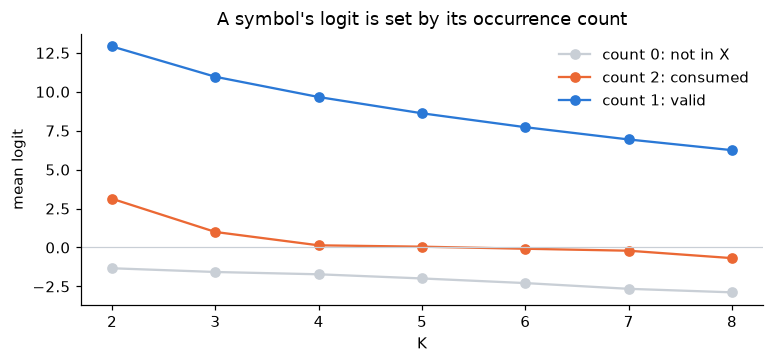

In [4]:
print(f"{'K':>2s} {'count 0 (not in X)':>19s} {'count 1 (valid)':>17s} {'count 2 (consumed)':>19s}")
for K, seqs in batches.items():
    logits, _ = model(torch.tensor(seqs))
    buck = {0: [], 1: [], 2: []}
    for b, toks in enumerate(seqs):
        for i in range(K + 1, 2 * K + 2):
            _, _, c = counts(toks, i)
            for s, cs in c.items(): buck[cs].append(float(logits[b, i, s]))
    print(f"{K:2d} " + " ".join(f"{np.mean(buck[c]):10.2f} +/- {np.std(buck[c]):4.2f}" for c in (0, 1, 2)))

K = 6; seqs = batches[K]; logits, _ = model(torch.tensor(seqs))
slot = {}
for b, toks in enumerate(seqs):
    for i in range(K + 1, 2 * K + 2):
        X, consumed, _ = counts(toks, i)
        for j, s in enumerate(toks[1:K + 1]):
            if s not in consumed: slot.setdefault(j, []).append(float(logits[b, i, s]))
print(f"\nvalid symbols at K={K}, grouped by their slot inside X: " + " ".join(f"slot {j}: {np.mean(v):.2f}" for j, v in sorted(slot.items())))

fig, ax = plt.subplots(figsize=(7, 3.4))
for c, col, lab in [(0, "#c9cfd6", "count 0: not in X"), (2, "#eb6834", "count 2: consumed"), (1, "#2a78d6", "count 1: valid")]:
    ys = []
    for K, seqs in batches.items():
        lg, _ = model(torch.tensor(seqs)); v = []
        for b, toks in enumerate(seqs):
            for i in range(K + 1, 2 * K + 2):
                _, _, cc = counts(toks, i)
                v += [float(lg[b, i, s]) for s, cs in cc.items() if cs == c]
        ys.append(np.mean(v))
    ax.plot(list(batches), ys, marker="o", color=col, label=lab)
ax.axhline(0, color="#c9cfd6", lw=0.8); ax.set_xlabel("K"); ax.set_ylabel("mean logit"); ax.legend(frameon=False)
ax.set_title("A symbol's logit is set by its occurrence count")
plt.tight_layout(); plt.show()

## 5. Where the count comes from: the two heads pull in opposite directions

Split the logit into its three exact pieces. Layer 1 supplies a large positive bonus to every symbol of $X$ and the same bonus whether or not the symbol has been consumed, so it carries membership and nothing else. Layer 0 supplies a negative amount that doubles when the symbol has been seen twice, so it carries the count. The embedding contributes almost nothing.

In [5]:
rng = random.Random(3)
print(f"{'K':>2s} {'count':>6s} {'embedding':>10s} {'layer 0':>9s} {'layer 1':>9s} {'total':>8s}")
for K in (3, 5, 8):
    acc = {c: [] for c in (0, 1, 2)}
    for _ in range(120):
        toks = make_prompt(rng, K); t = run(toks)
        for i in range(K + 1, 2 * K + 2):
            _, _, c = counts(toks, i); sc = float(rms(t["final"][i]))
            for s, cs in c.items():
                acc[cs].append([float(Uf[s] @ t[p][i]) / sc for p in ("embed", "L0", "L1")] + [float(t["logits"][i, s])])
    for c in (0, 1, 2):
        a = np.array(acc[c]).mean(0)
        print(f"{K:2d} {c:6d} {a[0]:10.2f} {a[1]:9.2f} {a[2]:9.2f} {a[3]:8.2f}")
    a1, a2 = np.array(acc[1]).mean(0), np.array(acc[2]).mean(0)
    print(f"   -> second occurrence costs {a2[1] - a1[1]:.2f} through layer 0, while layer 1 moves only {a2[2] - a1[2]:.2f}\n")

 K  count  embedding   layer 0   layer 1    total


 3      0       0.16      4.43     -6.15    -1.56
 3      1       0.05    -13.93     24.85    10.98
 3      2      -1.54    -26.23     28.77     1.00
   -> second occurrence costs -12.31 through layer 0, while layer 1 moves only 3.92



 5      0       0.21      7.02     -9.23    -2.00
 5      1       0.10     -7.08     15.59     8.61
 5      2      -1.01    -22.56     23.61     0.04
   -> second occurrence costs -15.48 through layer 0, while layer 1 moves only 8.02



 8      0       0.20      7.80    -10.86    -2.86
 8      1       0.15     -3.21      9.32     6.27
 8      2      -0.52    -10.85     10.70    -0.67
   -> second occurrence costs -7.64 through layer 0, while layer 1 moves only 1.38



### 5a. Layer 0 is a uniform counting head

Its attention over the symbol tokens seen so far is flat to within a standard deviation of $0.0001$, with separate weights for $\mathrm{BOS}$ and $\mathrm{SEP}$. A symbol that has occurred twice therefore enters the average with twice the weight of one that has occurred once. Its OV circuit is a negative copy: reading a symbol pushes that same symbol's logit **down**, by about fifteen times more than it moves any other symbol.

### 5b. Layer 1 is a membership head parked on SEP

At every scored position it places weight $1.000$ on $\mathrm{SEP}$, and only at the very last position does it move. The residual at $\mathrm{SEP}$ is layer 0's average over the $X$ block, so reading it once delivers the whole set. Its OV circuit is a positive copy of the same shape as layer 0's, with the opposite sign. The two circuits having opposite signs is what makes a second occurrence cancel the first.

In [6]:
rng = random.Random(7)
print("layer-0 attention from scored positions")
for K in (3, 5, 8):
    toks = make_prompt(rng, K); t = run(toks)
    for i in (K + 1, 2 * K + 1):
        row = t["p0"][i, :i + 1]
        sym = [j for j in range(i + 1) if toks[j] < NUM_SYMBOLS]
        print(f"  K={K} d={i - K - 1}: on symbol tokens {float(row[sym].sum()):.3f}"
              f" (each {float(row[sym].mean()):.4f}, sd {float(row[sym].std()):.4f}), BOS {float(row[0]):.3f}, SEP {float(row[K + 1]):.3f}")

print("\nlayer-1 attention on SEP, by distance d past SEP")
for K in (4, 6, 8):
    acc = {}
    for _ in range(100):
        toks = make_prompt(rng, K); t = run(toks)
        for i in range(K + 1, 2 * K + 2): acc.setdefault(i - K - 1, []).append(float(t["p1"][i, K + 1]))
    print(f"  K={K}: " + " ".join(f"d={d}:{np.mean(v):.3f}" for d, v in sorted(acc.items())))

print("\nOV circuits: entry [s, t] is how much reading token t moves symbol s's own logit")
for name, blk in (("layer 0", b0), ("layer 1", b1)):
    OV = blk.attn.W_O.weight @ blk.attn.W_V.weight
    M = ((Uf @ OV) @ (E * blk.ln_attn.weight).T)[:NUM_SYMBOLS, :NUM_SYMBOLS]
    d = M.diag(); off = (M.sum() - d.sum()) / (NUM_SYMBOLS * (NUM_SYMBOLS - 1))
    print(f"  {name}: diagonal {d.mean():+.4f}   off-diagonal {off:+.4f}   ratio {abs(d.mean() / off):.1f}x")

layer-0 attention from scored positions
  K=3 d=0: on symbol tokens 0.485 (each 0.1618, sd 0.0000), BOS 0.263, SEP 0.252
  K=3 d=3: on symbol tokens 0.642 (each 0.1071, sd 0.0001), BOS 0.221, SEP 0.137
  K=5 d=0: on symbol tokens 0.616 (each 0.1232, sd 0.0000), BOS 0.192, SEP 0.192
  K=5 d=5: on symbol tokens 0.902 (each 0.0902, sd 0.0001), BOS 0.068, SEP 0.030
  K=8 d=0: on symbol tokens 0.764 (each 0.0955, sd 0.0000), BOS 0.087, SEP 0.149
  K=8 d=8: on symbol tokens 0.980 (each 0.0613, sd 0.0001), BOS 0.007, SEP 0.013

layer-1 attention on SEP, by distance d past SEP
  K=4: d=0:1.000 d=1:1.000 d=2:0.999 d=3:0.985 d=4:0.873
  K=6: d=0:1.000 d=1:1.000 d=2:1.000 d=3:1.000 d=4:0.998 d=5:0.988 d=6:0.884
  K=8: d=0:1.000 d=1:0.999 d=2:0.999 d=3:0.999 d=4:1.000 d=5:1.000 d=6:1.000 d=7:0.989 d=8:0.485

OV circuits: entry [s, t] is how much reading token t moves symbol s's own logit
  layer 0: diagonal -0.0316   off-diagonal +0.0022   ratio 14.1x
  layer 1: diagonal +0.0040   off-diagonal -0.

## 6. The cancellation condition

Fit $\ell_s = \alpha_K [s \in X] - \beta_K \cdot \mathrm{count}(s) + c$ at each $K$. A consumed symbol scores $\alpha_K - 2\beta_K$, so for consumption to wipe out membership the weights must satisfy $\alpha_K = 2\beta_K$. They do, at every $K$, to within about two logits out of twenty. Both coefficients shrink as $K$ grows, which is the $1/n$ of layer 0's average: with more tokens in the sequence each one takes a smaller share.

 K   alpha    beta  2*beta  alpha-2beta  count-2 logit    R^2


 2   24.05    9.79   19.59         4.47           3.14  0.869
 3   22.49    9.96   19.92         2.57           1.00  0.888


 4   20.91    9.53   19.06         1.85           0.14  0.857


 5   19.20    8.58   17.16         2.04           0.05  0.838


 6   17.80    7.80   15.60         2.20          -0.09  0.822


 7   16.73    7.14   14.29         2.45          -0.20  0.803


 8   16.05    6.92   13.84         2.21          -0.69  0.768


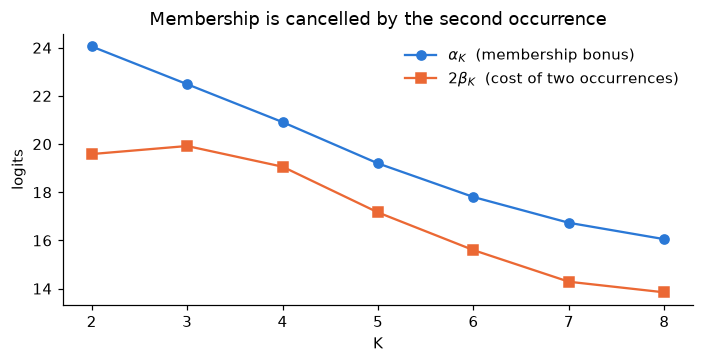

In [7]:
rng = random.Random(21)
print(f"{'K':>2s} {'alpha':>7s} {'beta':>7s} {'2*beta':>7s} {'alpha-2beta':>12s} {'count-2 logit':>14s} {'R^2':>6s}")
ALPHA, BETA = {}, {}
for K in range(2, 9):
    rows, ys, c2 = [], [], []
    for _ in range(100):
        toks = make_prompt(rng, K)
        logits, _ = model(torch.tensor([toks]))
        for i in range(K + 1, 2 * K + 2):
            X, _, c = counts(toks, i)
            for s, cs in c.items():
                rows.append([float(s in X), float(cs), 1.0]); ys.append(float(logits[0, i, s]))
                if cs == 2: c2.append(float(logits[0, i, s]))
    A, y = np.array(rows), np.array(ys)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    r2 = 1 - ((A @ coef - y) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    ALPHA[K], BETA[K] = coef[0], -coef[1]
    print(f"{K:2d} {coef[0]:7.2f} {-coef[1]:7.2f} {-2*coef[1]:7.2f} {coef[0]+2*coef[1]:12.2f} {np.mean(c2):14.2f} {r2:6.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
Ks = list(ALPHA)
ax.plot(Ks, [ALPHA[K] for K in Ks], marker="o", color="#2a78d6", label=r"$\alpha_K$  (membership bonus)")
ax.plot(Ks, [2 * BETA[K] for K in Ks], marker="s", color="#eb6834", label=r"$2\beta_K$  (cost of two occurrences)")
ax.set_xlabel("K"); ax.set_ylabel("logits"); ax.legend(frameon=False)
ax.set_title("Membership is cancelled by the second occurrence")
plt.tight_layout(); plt.show()

## 7. Causal tests on the count

Two interventions on layer 0's attention row, holding everything else fixed.

**Add an occurrence.** Double the weight layer 0 puts on one not-yet-consumed symbol's position in the $X$ block and renormalise. That symbol alone should fall toward the consumed level, and it does.

**Remove the occurrences.** Delete the $Y$ block from layer 0's average and renormalise, so every symbol of $X$ is counted once again. The gap between consumed and remaining symbols should collapse, and it does, from about 15 logits to about 1.

In [8]:
rng = random.Random(11)
print("adding one occurrence to a single symbol")
for K in (4, 6):
    before, after, cons = [], [], []
    for _ in range(80):
        toks = make_prompt(rng, K); i = K + 2
        t = run(toks); X, consumed, _ = counts(toks, i)
        cand = [(j + 1, s) for j, s in enumerate(toks[1:K + 1]) if s not in consumed]
        pos, s = cand[0]
        row = t["p0"][i].clone(); row[pos] *= 2; row /= row.sum()
        before.append(float(t["logits"][i, s]))
        after.append(float(run(toks, l0_row={i: row})["logits"][i, s]))
        cons.append(np.mean([float(t["logits"][i, ss]) for ss in consumed]))
    print(f"  K={K}: that symbol {np.mean(before):6.2f} -> {np.mean(after):6.2f};  genuinely consumed symbols sit at {np.mean(cons):6.2f}")

print("\ndeleting the Y block from layer 0's average")
for K in (4, 6):
    rows = []
    for _ in range(80):
        toks = make_prompt(rng, K); i = 2 * K
        t = run(toks); X, consumed, _ = counts(toks, i)
        rem = sorted(X - consumed); con = sorted(consumed)
        row = t["p0"][i].clone(); row[K + 2:] = 0; row /= row.sum()
        t2 = run(toks, l0_row={i: row})
        rows.append([float(t["logits"][i, con].mean()), float(t["logits"][i, rem].mean()),
                     float(t2["logits"][i, con].mean()), float(t2["logits"][i, rem].mean())])
    a = np.array(rows).mean(0)
    print(f"  K={K}: normal     consumed {a[0]:6.2f}  remaining {a[1]:6.2f}  gap {a[1]-a[0]:5.2f}")
    print(f"  K={K}: Y deleted  consumed {a[2]:6.2f}  remaining {a[3]:6.2f}  gap {a[3]-a[2]:5.2f}")

adding one occurrence to a single symbol
  K=4: that symbol   9.34 ->   3.19;  genuinely consumed symbols sit at  -1.10
  K=6: that symbol   6.69 ->   0.75;  genuinely consumed symbols sit at  -2.98

deleting the Y block from layer 0's average


  K=4: normal     consumed  -0.52  remaining  15.43  gap 15.95
  K=4: Y deleted  consumed   5.47  remaining   6.48  gap  1.01
  K=6: normal     consumed   0.25  remaining  14.84  gap 14.59
  K=6: Y deleted  consumed   4.23  remaining   5.28  gap  1.05


## 8. EOS is a length match, not an empty set

Three facts, in order.

**The value at SEP suppresses EOS.** Force layer 1 at the final position onto each key in turn. Parking on $\mathrm{SEP}$ gives an $\mathrm{EOS}$ logit near zero; every other key in the sequence gives twenty to a hundred. $\mathrm{EOS}$ is the default and sitting on $\mathrm{SEP}$ is what holds it down. So the model emits $\mathrm{EOS}$ by *leaving* $\mathrm{SEP}$, not by finding anything.

**The attention leaves SEP at exactly $d = K$.** The best competing key's score minus the $\mathrm{SEP}$ key's score rises with $d$ and reaches zero at $d = K$, for every $K$. Two ingredients set the crossing. Rotary position makes the competing keys gain score as the query moves away from $\mathrm{SEP}$, and layer 0's average over the $K$ symbols sitting before $\mathrm{SEP}$ sets how high the $\mathrm{SEP}$ key starts. Reading the table down a column shows the second ingredient: at a fixed distance the gap still grows with $K$, so this is not rotation alone.

**The rule is about lengths.** Feeding $Y$ sequences that are not permutations separates the two candidate rules. Hold the number of symbols after $\mathrm{SEP}$ at $K$ but let $Y$ repeat symbols, so some symbols of $X$ are never consumed: $\mathrm{EOS}$ still fires. Hold the set empty but keep going past $K$: $\mathrm{EOS}$ keeps firing. Vary the length and the model switches to $\mathrm{EOS}$ at $L = K$ whatever the set looks like. On the training distribution $Y$ is always a permutation, so the two rules coincide and the model only ever needed the easier one.

In [9]:
rng = random.Random(51)
print("EOS logit with layer 1 forced onto each key, at the final position (K=6)")
K = 6; acc = {}
for _ in range(50):
    toks = make_prompt(rng, K); i = 2 * K + 1
    t = run(toks)
    for key in range(i + 1):
        row = torch.zeros(len(toks)); row[key] = 1.0
        role = "BOS" if key == 0 else ("SEP" if key == K + 1 else (f"x{key}" if key <= K else f"y{key - K - 1}"))
        acc.setdefault((key, role), []).append(float(run(toks, l1_row={i: row})["logits"][i, EOS]))
for (key, role), v in sorted(acc.items()):
    print(f"  key {key:2d} ({role:4s}): EOS {np.mean(v):8.2f}  " + "#" * max(0, int(np.mean(v) / 4)))

print("\nbest competing key minus the SEP key, by distance past SEP (negative means SEP still wins)")
tab = {}
for K in range(2, 9):
    for _ in range(60):
        toks = make_prompt(rng, K); t = run(toks)
        for i in range(K + 2, 2 * K + 2):
            other = [j for j in range(i + 1) if j != K + 1]
            tab.setdefault((K, i - K - 1), []).append(float(t["s1"][i, other].max() - t["s1"][i, K + 1]))
print("       " + "".join(f"d={d:<6d}" for d in range(1, 9)))
for K in range(2, 9):
    print(f"  K={K}  " + "".join(f"{np.mean(tab[(K,d)]):+7.2f} " if (K, d) in tab else "        " for d in range(1, 9)))
print("  the sign flips at d = K along every row, and down any column the gap still grows with K")

print("\nvarying the length of Y independently of its content")
for K in (4, 6):
    print(f"  K={K}")
    print(f"    {'L':>2s} {'symbols left':>13s} {'EOS logit':>10s} {'best symbol':>12s} {'EOS wins':>9s}")
    for L in range(1, K + 3):
        e, top, win, left = [], [], [], []
        for _ in range(60):
            X = rng.sample(range(NUM_SYMBOLS), K)
            Y = [X[rng.randrange(K)] for _ in range(L)]
            lg = model(torch.tensor([[BOS] + X + [SEP] + Y + [EOS]]))[0][0, K + 1 + L]
            e.append(float(lg[EOS])); top.append(float(lg[:NUM_SYMBOLS].max()))
            win.append(float(lg[EOS]) > float(lg[:NUM_SYMBOLS].max())); left.append(len(set(X) - set(Y)))
        print(f"    {L:2d} {np.mean(left):13.2f} {np.mean(e):10.2f} {np.mean(top):12.2f} {np.mean(win):9.2f}" + ("   <- L = K" if L == K else ""))

print("\n  the set is empty from L=K on, yet EOS keeps rising with L:")
for K in (4, 6):
    out = []
    for L in range(K, K + 4):
        e = []
        for _ in range(60):
            X = rng.sample(range(NUM_SYMBOLS), K); Y = X[:]; rng.shuffle(Y)
            Y += [X[rng.randrange(K)] for _ in range(L - K)]
            e.append(float(model(torch.tensor([[BOS] + X + [SEP] + Y + [EOS]]))[0][0, K + 1 + L, EOS]))
        out.append(f"L={L}: {np.mean(e):7.2f}")
    print(f"    K={K}: " + "   ".join(out))

EOS logit with layer 1 forced onto each key, at the final position (K=6)


  key  0 (BOS ): EOS    26.49  ######
  key  1 (x1  ): EOS    19.42  ####
  key  2 (x2  ): EOS    24.21  ######
  key  3 (x3  ): EOS    30.41  #######
  key  4 (x4  ): EOS    35.24  ########
  key  5 (x5  ): EOS    42.85  ##########
  key  6 (x6  ): EOS    56.75  ##############
  key  7 (SEP ): EOS     0.25  
  key  8 (y1  ): EOS    88.54  ######################
  key  9 (y2  ): EOS    73.85  ##################
  key 10 (y3  ): EOS    65.39  ################
  key 11 (y4  ): EOS    62.44  ###############
  key 12 (y5  ): EOS    69.85  #################
  key 13 (y6  ): EOS   113.92  ############################

best competing key minus the SEP key, by distance past SEP (negative means SEP still wins)


       d=1     d=2     d=3     d=4     d=5     d=6     d=7     d=8     
  K=2    -4.16   -1.12                                                 
  K=3    -7.93   -4.81   -1.90                                         
  K=4   -10.10   -7.68   -4.81   -2.57                                 
  K=5   -10.20   -8.61   -7.12   -5.19   -2.79                         
  K=6    -9.17   -8.93   -8.59   -6.96   -4.68   -2.05                 
  K=7    -8.26   -8.51   -8.73   -8.49   -7.35   -4.90   -1.71         
  K=8    -7.59   -7.23   -7.37   -8.99  -10.06   -8.05   -4.46   +0.10 
  the sign flips at d = K along every row, and down any column the gap still grows with K

varying the length of Y independently of its content
  K=4
     L  symbols left  EOS logit  best symbol  EOS wins
     1          3.00      -8.10         9.32      0.00
     2          2.25      -6.17        10.71      0.00
     3          1.78      -0.75        11.34      0.00
     4          1.27      15.32         9.93      0.92

     6          0.68      71.31         2.71      1.00
  K=6
     L  symbols left  EOS logit  best symbol  EOS wins
     1          5.00     -11.13         6.68      0.00
     2          4.08      -9.17         7.56      0.00
     3          3.58      -6.13         7.87      0.00
     4          2.98      -3.34         8.59      0.00


     5          2.25       0.20         9.68      0.00
     6          1.90      13.88         9.65      1.00   <- L = K
     7          1.55      62.51         8.72      1.00
     8          1.25      78.48         9.09      1.00

  the set is empty from L=K on, yet EOS keeps rising with L:


    K=4: L=4:   22.48   L=5:   63.67   L=6:   81.69   L=7:   76.19


    K=6: L=6:   25.05   L=7:   78.82   L=8:   89.21   L=9:   81.65


## 9. The whole model from two rules

Take the fitted $\alpha_K$ and $\beta_K$ from section 6 and nothing else from the network. Score every symbol by membership minus count, answer $\mathrm{EOS}$ once $d = K$, and compare against what the model actually ranks first.

In [10]:
rng = random.Random(61); agree = []
for K in range(2, 9):
    for _ in range(200):
        toks = make_prompt(rng, K)
        logits, _ = model(torch.tensor([toks]))
        for i in range(K + 1, 2 * K + 2):
            X, consumed, c = counts(toks, i)
            got = int(logits[0, i].argmax())
            if i - (K + 1) == K:
                agree.append(got == EOS)                                     # rule B
            else:
                pred = {s: ALPHA[K] * (s in X) - BETA[K] * c[s] for s in range(NUM_SYMBOLS)}
                best = max(pred.values())
                agree.append(got in [s for s, v in pred.items() if v > best - 1e-9])   # rule A
print(f"the two rules reproduce the model's top choice at {np.mean(agree):.4f} of all scored positions")

the two rules reproduce the model's top choice at 1.0000 of all scored positions


## 10. The algorithm, written out

**Input.** $[\mathrm{BOS}]\, x_1 \dots x_K\, [\mathrm{SEP}]\, y_1 \dots y_K\, [\mathrm{EOS}]$ with $X = \{x_1, \dots, x_K\}$ and $Y$ a permutation of $X$. At query position $i$ write $d = i - (K+1)$ and $\mathrm{count}(s)$ for the number of times $s$ has appeared at or before $i$, which is $[s \in X] + [s \in \{y_1, \dots, y_d\}]$.

**Layer 0, the counting head.** Attends uniformly over every symbol token seen so far, with separate fixed weights on $\mathrm{BOS}$ and $\mathrm{SEP}$. Its OV circuit is a negative copy, so it writes

$$-\,\frac{\beta_K}{\text{(normalisation)}} \sum_{s} \mathrm{count}(s)\, \hat{u}_s + \text{const} .$$

**Layer 1, the membership head.** Attends to $\mathrm{SEP}$ with weight $1.000$ for all $d < K$. The residual at $\mathrm{SEP}$ is layer 0's average over the $X$ block, and layer 1's OV circuit is a positive copy, so it writes $+\alpha_K \sum_{s \in X} \hat{u}_s$, the same vector at every step.

**Readout.**

$$\ell_s \;\approx\; \alpha_K\,[s \in X] - \beta_K\,\mathrm{count}(s), \qquad \alpha_K \approx 2\beta_K,$$

$$\ell_s \approx \begin{cases} 0 & s \notin X \\ +\beta_K & s \in X,\ \text{not yet consumed} \\ \approx 0 & s \in X,\ \text{consumed} \end{cases}$$

Every surviving symbol gets the identical score, which is where the uniform output comes from.

**EOS.** The value at $\mathrm{SEP}$ is the only one carrying a negative $\mathrm{EOS}$ component, so layer 1 sitting on $\mathrm{SEP}$ suppresses $\mathrm{EOS}$. Rotary position raises the competing keys' scores as $d$ grows while layer 0's $K$-symbol average sets the $\mathrm{SEP}$ key's starting height; they cross at $d = K$, attention leaks off $\mathrm{SEP}$, and $\mathrm{EOS}$ comes through. The learned rule is "as many symbols after $\mathrm{SEP}$ as before it", which matches the task only because $Y$ is always a permutation of $X$.

**The connection to September.** Last month's 108-parameter model placed its symbol embeddings on the one curve where an $X$ copy and a $Y$ copy of the same symbol contribute equal and opposite amounts, so that repeated symbols vanish and the lone symbol survives. This model does the same arithmetic with a different device: two copy circuits of opposite sign, tuned so that $\alpha_K = 2\beta_K$. Both tasks are "find what appears an odd number of times", and both models solve it by cancellation instead of by comparison. The new ingredient here is that the cancellation has to hold at every step of a shrinking set and across seven different values of $K$, which is what the $1/n$ scaling of the counting head buys.